In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import os
import re 
import sys
import datetime
import random
from pathlib import Path
import warnings
import cartopy.feature as cfeature
import cartopy.crs as ccrs

import dask
#import dask.array as da
from dask.distributed import Client
#from dask.diagnostics import ProgressBar

# dask version 2024.12 has much faster quantile calculation, however it seems to crash this code
print(f"Dask version: {dask.__version__}")

client = Client()
client

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3_edge-25.11/share/proj failed


Dask version: 2025.10.0


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 48,Total memory: 250.26 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39195,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33089,Total threads: 6
Dashboard: http://127.0.0.1:41119/status,Memory: 31.28 GiB
Nanny: tcp://127.0.0.1:36015,


In [6]:
## NARCliM metadata

def configuration(in_text):
    if "ACCESS-ESM1-5" in in_text:
        return "r6i1p1f1"
    elif "UKESM1-0-LL" in in_text:
        return "r1i1p1f2"
    elif "EC-Earth3-Veg" in in_text:
        return "r1i1p1f1"
    elif "MPI-ESM1-2-HR" in in_text:
        return "r1i1p1f1"
    elif "NorESM2-MM" in in_text:
        return "r1i1p1f1"

def days_year(in_text):
    if "ACCESS-ESM1-5" in in_text:
        return 365
    elif "UKESM1-0-LL" in in_text:
        return 360
    elif "EC-Earth3-Veg" in in_text:
        return 365.25
    elif "MPI-ESM1-2-HR" in in_text:
        return 365.25
    elif "NorESM2-MM" in in_text:
        return 365
#4km SE Australia domain
n2_list = ['/g/data/zz63/NARCliM2-0/output-CMIP6/DD/NARCliM2-0-SEAus-04/NSW-Government/ACCESS-ESM1-5/historical/r6i1p1f1/NARCliM2-0-WRF412R5/v1-r1/day',
           '/g/data/zz63/NARCliM2-0/output-CMIP6/DD/NARCliM2-0-SEAus-04/NSW-Government/ACCESS-ESM1-5/historical/r6i1p1f1/NARCliM2-0-WRF412R3/v1-r1/day',
           '/g/data/zz63/NARCliM2-0/output-CMIP6/DD/NARCliM2-0-SEAus-04/NSW-Government/NorESM2-MM/historical/r1i1p1f1/NARCliM2-0-WRF412R5/v1-r1/day',
            '/g/data/zz63/NARCliM2-0/output-CMIP6/DD/NARCliM2-0-SEAus-04/NSW-Government/NorESM2-MM/historical/r1i1p1f1/NARCliM2-0-WRF412R3/v1-r1/day',
            '/g/data/zz63/NARCliM2-0/output-CMIP6/DD/NARCliM2-0-SEAus-04/NSW-Government/UKESM1-0-LL/historical/r1i1p1f2/NARCliM2-0-WRF412R5/v1-r1/day',
            '/g/data/zz63/NARCliM2-0/output-CMIP6/DD/NARCliM2-0-SEAus-04/NSW-Government/UKESM1-0-LL/historical/r1i1p1f2/NARCliM2-0-WRF412R3/v1-r1/day',
            '/g/data/zz63/NARCliM2-0/output-CMIP6/DD/NARCliM2-0-SEAus-04/NSW-Government/EC-Earth3-Veg/historical/r1i1p1f1/NARCliM2-0-WRF412R5/v1-r1/day',
            '/g/data/zz63/NARCliM2-0/output-CMIP6/DD/NARCliM2-0-SEAus-04/NSW-Government/EC-Earth3-Veg/historical/r1i1p1f1/NARCliM2-0-WRF412R3/v1-r1/day',
            '/g/data/zz63/NARCliM2-0/output-CMIP6/DD/NARCliM2-0-SEAus-04/NSW-Government/MPI-ESM1-2-HR/historical/r1i1p1f1/NARCliM2-0-WRF412R3/v1-r1/day',
            '/g/data/zz63/NARCliM2-0/output-CMIP6/DD/NARCliM2-0-SEAus-04/NSW-Government/MPI-ESM1-2-HR/historical/r1i1p1f1/NARCliM2-0-WRF412R5/v1-r1/day']
## 20km CORDEX domain
n2_list_aus18 = ['/g/data/zz63/NARCliM2-0/output-CMIP6/DD/AUS-18/NSW-Government/ACCESS-ESM1-5/historical/r6i1p1f1/NARCliM2-0-WRF412R5/v1-r1/day',
           '/g/data/zz63/NARCliM2-0/output-CMIP6/DD/AUS-18/NSW-Government/ACCESS-ESM1-5/historical/r6i1p1f1/NARCliM2-0-WRF412R3/v1-r1/day',
           '/g/data/zz63/NARCliM2-0/output-CMIP6/DD/AUS-18/NSW-Government/NorESM2-MM/historical/r1i1p1f1/NARCliM2-0-WRF412R5/v1-r1/day',
            '/g/data/zz63/NARCliM2-0/output-CMIP6/DD/AUS-18/NSW-Government/NorESM2-MM/historical/r1i1p1f1/NARCliM2-0-WRF412R3/v1-r1/day',
            '/g/data/zz63/NARCliM2-0/output-CMIP6/DD/AUS-18/NSW-Government/UKESM1-0-LL/historical/r1i1p1f2/NARCliM2-0-WRF412R5/v1-r1/day',
            '/g/data/zz63/NARCliM2-0/output-CMIP6/DD/AUS-18/NSW-Government/UKESM1-0-LL/historical/r1i1p1f2/NARCliM2-0-WRF412R3/v1-r1/day',
            '/g/data/zz63/NARCliM2-0/output-CMIP6/DD/AUS-18/NSW-Government/EC-Earth3-Veg/historical/r1i1p1f1/NARCliM2-0-WRF412R5/v1-r1/day',
            '/g/data/zz63/NARCliM2-0/output-CMIP6/DD/AUS-18/NSW-Government/EC-Earth3-Veg/historical/r1i1p1f1/NARCliM2-0-WRF412R3/v1-r1/day',
            '/g/data/zz63/NARCliM2-0/output-CMIP6/DD/AUS-18/NSW-Government/MPI-ESM1-2-HR/historical/r1i1p1f1/NARCliM2-0-WRF412R3/v1-r1/day',
            '/g/data/zz63/NARCliM2-0/output-CMIP6/DD/AUS-18/NSW-Government/MPI-ESM1-2-HR/historical/r1i1p1f1/NARCliM2-0-WRF412R5/v1-r1/day']


labels = ["ACCESS_R3","ACCESS_R5","EC_EARTH_R3","EC_EARTH_R5","MPI_ESM_R3","MPI_ESM_R5","NORESM_R3","NORESM_R5","UKESM_R3","UKESM_R5"]



os.chdir("/home/569/pw4923/identify_ce")
rlon_04 = (open('rlon-correction-NARCliM2-0-SEAus-04.txt')) # Can be downloaded from zz63 project
rlon_04fix = rlon_04.read().splitlines()
rlon_20 = (open('rlon-correction-AUS-18.txt'))
rlon_20fix = rlon_20.read().splitlines()

# Rotated pole projection for dealing with native grid rotated pole data
rotated_pole = ccrs.RotatedPole(pole_longitude=141.38,   # West longitude
                                pole_latitude=60.31)     # North latitude


In [7]:
# Set data root to be loaded

nvar1 = "pr" # "ta500"
nvar2 = "sfcWindmax" #"tasmin" 

gcm = "ACCESS-ESM1-5" #Options are ACCESS-ESM1-5 ; EC-Earth3-Veg ; MPI-ESM1-2-HR ; NorESM2-MM ; UKESM1-0-LL
rcm = "NARCliM2-0-WRF412R5" #Options are NARCliM2-0-WRF412R5 and R3
scenario = "historical" #Options are ssp126, ssp370 and historical
config = configuration(gcm)
#start_time = "2080-01-01" # earliest 1950-01-01 for historical, 2015-01-01 for ssp
start_time = "1985-01-01"
end_time = "2014-12-30"
#latest 2014-12-31 for historical, 2100-12-31 for ssp

config = configuration(gcm)
domain = "NARCliM2-0-SEAus-04" # Options are NARCliM2-0-SEAus-04 or AUS-18
if domain == "NARCliM2-0-SEAus-04":
    res = '04'
if domain == "AUS-18":
    res = '20'
config = configuration(gcm)
# Path to parent directory containing input files
data_root = "/g/data/zz63/NARCliM2-0/output-CMIP6/DD/"+domain+"/NSW-Government/"+gcm+"/"+scenario+"/"+config+"/"+rcm+"/v1-r1/day"


In [8]:
def open_and_prepare_variable(data_root, var_name,start_time=None,end_time=None):
    """
    Open and prepare the dataset of a variable.
    """
    def _preprocess(ds): 
        ds = ds[(list(ds.keys()))[0]]
        return ds
    
    latest_data_root = Path(os.path.join(data_root, var_name, "latest"))
    file_paths = [fp for fp in (latest_data_root.glob("*.nc")) if re.search(var_name,fp.name)]
    file_paths.sort()
    dataset = xr.open_mfdataset(file_paths, parallel=True, preprocess=_preprocess, engine="h5netcdf", join='outer', chunks={"time":-1})    
    os.chdir("/home/569/pw4923/identify_ce")
    a = (open('rlon-correction-NARCliM2-0-SEAus-04.txt'))
    #a = (open('rlon-correction-AUS-18.txt'))
    b = a.read().splitlines()
    dataset['rlon'] = b
    if start_time is None:
        start_time = np.ravel(dataset.time[0].dt.strftime("%Y-%m-%d"))[0]
    if end_time is None:
        end_time = np.ravel(dataset.time[-1].dt.strftime("%Y-%m-%d"))[0]
    dataset = dataset.sel(time=slice(start_time,end_time))
    return dataset

In [9]:
data_root

'/g/data/zz63/NARCliM2-0/output-CMIP6/DD/NARCliM2-0-SEAus-04/NSW-Government/ACCESS-ESM1-5/historical/r6i1p1f1/NARCliM2-0-WRF412R5/v1-r1/day'

In [10]:
var1 = open_and_prepare_variable(data_root,'pr')

In [11]:
var1

<xarray.Dataset> Size: 26GB
Dimensions:  (time: 23376, rlat: 474, rlon: 594)
Coordinates:
  * time     (time) datetime64[ns] 187kB 1951-01-01T12:00:00 ... 2014-12-31T1...
  * rlat     (rlat) float64 4kB -10.53 -10.49 -10.46 -10.42 ... 6.05 6.09 6.12
  * rlon     (rlon) <U19 45kB '174.4917144803018' ... '-164.63466025066333'
    lat      (rlat, rlon) float64 2MB dask.array<chunksize=(474, 594), meta=np.ndarray>
    lon      (rlat, rlon) float64 2MB dask.array<chunksize=(474, 594), meta=np.ndarray>
Data variables:
    pr       (time, rlat, rlon) float32 26GB dask.array<chunksize=(365, 474, 594), meta=np.ndarray>

In [11]:
var2 = open_and_prepare_variable(data_root,'tasmax')

In [ ]:
var2 = var2.chunk({"time":-1, "rlat":"auto", "rlon":"auto"}).unify_chunks()
#
#p99.tasmax.plot()

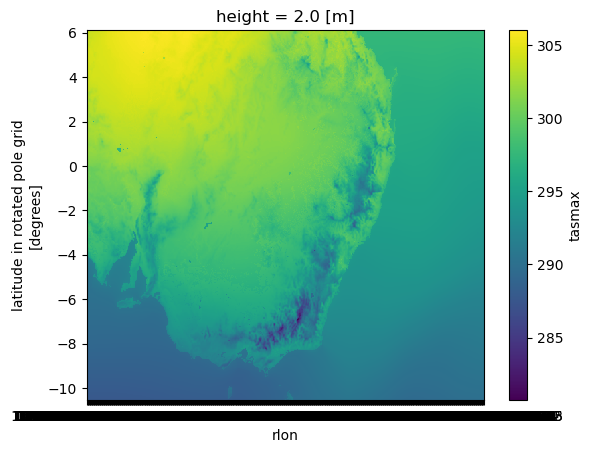

In [15]:
var2_mean = var2.mean(dim='time')
var2_mean['tasmax'].plot()

In [ ]:
p99 = var2.quantile(0.99,dim=['time']).compute()